# Model Training & Evaluation

Train a Numba-jitted Linear State-Space Model (LSSM) that maps EMG -> joint angles using one or more preprocessed `df_model` files written by `data_preprocess.ipynb`.

Stages:
1. Config + imports
2. Load preprocessed training data (one or more episodes)
3. Feature setup (optional PCA on EMG / joints, fit pooled across episodes)
4. LSSM model definition
5. Train (hardcoded 50/50 split over loaded episodes)
6. Evaluation:
   - 6a. Learned dynamics
   - 6b. Multi-episode aggregate metrics across loaded episodes
   - 6c. Active-episode selection (one-line switch for the cells below)
   - 6d. Prediction plots (active episode)
   - 6e. Cross-correlation (active episode)
   - 6f. Joint plot + 3D arm animation (active episode)


## 1. Config & imports

In [34]:
import os
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from arm_inverse_kinematics import forward_kinematics_fixed, L1_FIXED, L2_FIXED
from arm_visualizer import ArmVisualizer

# ---------------- Config ----------------
TRAINING_DATA_DIR   = 'training_data'
# Which episodes to load. None -> all training_data_*.csv in TRAINING_DATA_DIR.
# Or a list of timestamps, e.g. ['20260425_011156', '20260425_013519'].
EPISODE_TIMESTAMPS  = None

# Feature setup
USE_PCA_EMG         = False    # if True, reduce EMG -> N components
USE_PCA_JOINT       = False    # if True, reduce joints -> N components
N_PCA_EMG           = 2
N_PCA_JOINT         = 2
JOINT_TARGETS       = ['q4']   # which joint columns to predict when not using PCA

# Model
STATE_DIM           = 8
N_RESTARTS          = 100
N_POLISH            = 10
N_BURNIN            = 0
L2_ALPHA            = 1e-4
STANDARDIZE         = True
LEARN_X0            = True
SEED                = 42

# Evaluation
EMG_SAMPLE_RATE_HZ  = 160       # used for FFT freq axis
VIZ_DOWNSAMPLE_N    = 600       # frames for the 3D arm animation


## 2. Load preprocessed training data

In [35]:
# Resolve which timestamps to load.
if EPISODE_TIMESTAMPS is None:
    paths = sorted(glob.glob(os.path.join(TRAINING_DATA_DIR, 'training_data_*.csv')))
    if not paths:
        raise FileNotFoundError(f'No training_data_*.csv files in {TRAINING_DATA_DIR}/')
    timestamps = [os.path.splitext(os.path.basename(p))[0].replace('training_data_', '')
                  for p in paths]
else:
    timestamps = list(EPISODE_TIMESTAMPS)
    paths = [os.path.join(TRAINING_DATA_DIR, f'training_data_{ts}.csv') for ts in timestamps]
    missing = [p for p in paths if not os.path.isfile(p)]
    if missing:
        raise FileNotFoundError(f'Missing training_data files: {missing}')

# Load each episode.
episodes = {ts: pd.read_csv(p) for ts, p in zip(timestamps, paths)}

# Derive EMG channel set from the first episode; assert consistency across all.
joint_cols_all = ['q1', 'q2', 'q3', 'q4']
first_ts = timestamps[0]
emg_cols = [c for c in episodes[first_ts].columns
            if c not in ['time'] + joint_cols_all]

for ts in timestamps[1:]:
    cols_here = [c for c in episodes[ts].columns
                 if c not in ['time'] + joint_cols_all]
    if cols_here != emg_cols:
        raise ValueError(
            f'EMG channel mismatch: episode {ts} has {cols_here}, '
            f'expected {emg_cols} (from {first_ts}).'
        )

# Summary table.
summary = pd.DataFrame([
    {
        'timestamp': ts,
        'rows': len(episodes[ts]),
        'duration_s': float(episodes[ts]['time'].iloc[-1] - episodes[ts]['time'].iloc[0]),
        'n_emg_channels': len(emg_cols),
    }
    for ts in timestamps
])
print(f'Loaded {len(episodes)} episodes from {TRAINING_DATA_DIR}/')
print(f'EMG channels  : {emg_cols}')
print(f'Joint columns : {joint_cols_all}')
print()
print(summary.to_string(index=False))


Loaded 16 episodes from training_data/
EMG channels  : ['Channel 3', 'Channel 4']
Joint columns : ['q1', 'q2', 'q3', 'q4']

      timestamp  rows  duration_s  n_emg_channels
20260425_011156  1698   11.125224               2
20260425_011228   149    0.896860               2
20260425_011242  1277    8.340232               2
20260425_011322  1606   10.523113               2
20260425_011355  1831   12.018761               2
20260425_011440  1090    7.046428               2
20260425_013051  1271    8.282173               2
20260425_013116  1062    6.872574               2
20260425_013137  1743   11.418886               2
20260425_013205  1401    9.202305               2
20260425_013233  2309   15.173965               2
20260425_013519  2707   17.885264               2
20260425_013607  1281    9.357828               2
20260425_013654  2276   16.214037               2
20260425_013734  1665   11.091337               2
20260425_013819  1553   10.146204               2


## 3. Feature setup (optional PCA)

Build `U` (inputs, EMG-derived) and `Z` (targets, joint-derived).
PCA is off by default — the model learns directly from EMG channels to the chosen joint targets.

In [36]:
from sklearn.decomposition import PCA

# Fit PCA (if enabled) on pooled frames across all loaded episodes.
# PCA is a per-frame linear projection, so pooling frames as samples is
# correct -- this is not temporal stitching.
if USE_PCA_EMG:
    pooled_emg = np.vstack([episodes[ts][emg_cols].values for ts in timestamps])
    pca_emg = PCA(n_components=N_PCA_EMG).fit(pooled_emg)
    print(f'EMG PCA: {pooled_emg.shape[1]} channels -> {N_PCA_EMG} components')
    print(f'  Explained variance ratio: {pca_emg.explained_variance_ratio_}')
    print(f'  Cumulative              : {pca_emg.explained_variance_ratio_.sum():.4f}')
else:
    pca_emg = None
    print(f'EMG PCA disabled.')

if USE_PCA_JOINT:
    pooled_joint = np.vstack([episodes[ts][joint_cols_all].values for ts in timestamps])
    pca_joint = PCA(n_components=N_PCA_JOINT).fit(pooled_joint)
    print(f'Joint PCA: 4 joints -> {N_PCA_JOINT} components')
    print(f'  Explained variance ratio: {pca_joint.explained_variance_ratio_}')
else:
    pca_joint = None
    print(f'Joint PCA disabled. Predicting columns: {JOINT_TARGETS}')


def build_UZ(df):
    """Apply the (optional) PCA transforms + JOINT_TARGETS selection to one episode."""
    emg = df[emg_cols].values
    U = pca_emg.transform(emg) if pca_emg is not None else emg

    joints = df[joint_cols_all].values
    Z = pca_joint.transform(joints) if pca_joint is not None else df[JOINT_TARGETS].values
    return U, Z


# Build (U, Z) once per loaded episode.
UZ = {ts: build_UZ(episodes[ts]) for ts in timestamps}

# Diagnostic print using the first episode.
U0, Z0 = UZ[timestamps[0]]
print(f'\nPer-episode shapes (first episode {timestamps[0]}):')
print(f'  U shape: {U0.shape}  range [{U0.min():.3f}, {U0.max():.3f}]')
print(f'  Z shape: {Z0.shape}  range [{Z0.min():.3f}, {Z0.max():.3f}]')


EMG PCA disabled.
Joint PCA disabled. Predicting columns: ['q4']

Per-episode shapes (first episode 20260425_011156):
  U shape: (1698, 2)  range [-10.154, 6.434]
  Z shape: (1698, 1)  range [1.427, 2.369]


## 4. LSSM model definition

Linear state-space model

$$x_{k+1} = A x_k + B u_k, \quad z_k = C x_k$$

Fit by prediction-error minimization with Numba-jitted forward/backward passes and analytic gradients via reverse-mode through the recursion. L-BFGS-B with multi-restart + polish.

In [37]:
"""
Linear State-Space Model with Numba-jitted forward and backward passes.

Model:
    x_{k+1} = A x_k + B u_k
    z_k     = C x_k

Fit by prediction-error minimization with x_0 = 0 (or learned), using a
hand-derived analytic gradient (reverse-mode through the recursion).
"""
import numpy as np
from numba import njit
from scipy.optimize import minimize


@njit
def _forward(U, A, B, C, x0):
    T = U.shape[0]
    p = C.shape[0]
    d = A.shape[0]
    m = U.shape[1]
    X = np.empty((T, d))
    Z_hat = np.empty((T, p))
    x = x0.copy()
    for k in range(T):
        for i in range(d):
            X[k, i] = x[i]
        for i in range(p):
            s = 0.0
            for j in range(d):
                s += C[i, j] * x[j]
            Z_hat[k, i] = s
        x_new = np.zeros(d)
        for i in range(d):
            s = 0.0
            for j in range(d):
                s += A[i, j] * x[j]
            for j in range(m):
                s += B[i, j] * U[k, j]
            x_new[i] = s
        x = x_new
    return X, Z_hat


@njit
def _backward_accumulate(U, Z, X, Z_hat, A, C, dA, dB, dC, dx0,
                         n_burnin, total_count):
    T = U.shape[0]
    p = C.shape[0]
    d = A.shape[0]
    m = U.shape[1]
    scale = 2.0 / total_count

    R = np.empty((T, p))
    sse = 0.0
    for k in range(T):
        if k < n_burnin:
            for i in range(p):
                R[k, i] = 0.0
        else:
            for i in range(p):
                r = Z_hat[k, i] - Z[k, i]
                R[k, i] = r
                sse += r * r

    for k in range(T):
        for i in range(p):
            for j in range(d):
                dC[i, j] += scale * R[k, i] * X[k, j]

    lam = np.zeros(d)
    for k in range(T - 1, -1, -1):
        if k < T - 1:
            for i in range(d):
                for j in range(d):
                    dA[i, j] += lam[i] * X[k, j]
                for j in range(m):
                    dB[i, j] += lam[i] * U[k, j]
        new_lam = np.zeros(d)
        for i in range(d):
            s = 0.0
            for j in range(p):
                s += C[j, i] * R[k, j]
            new_lam[i] = scale * s
            for j in range(d):
                new_lam[i] += A[j, i] * lam[j]
        lam = new_lam

    for i in range(d):
        dx0[i] += lam[i]

    return sse


@njit
def _step(x, u, A, B, C):
    """Single-step inference: returns (z_k, x_{k+1})."""
    d = A.shape[0]
    p = C.shape[0]
    m = u.shape[0]
    z = np.zeros(p)
    for i in range(p):
        s = 0.0
        for j in range(d):
            s += C[i, j] * x[j]
        z[i] = s
    x_next = np.zeros(d)
    for i in range(d):
        s = 0.0
        for j in range(d):
            s += A[i, j] * x[j]
        for j in range(m):
            s += B[i, j] * u[j]
        x_next[i] = s
    return z, x_next


class LSSM:
    """Linear state-space model fit by prediction-error minimization with analytic gradients."""

    def __init__(self, state_dim, input_dim, output_dim):
        self.d = state_dim
        self.m = input_dim
        self.p = output_dim
        self.A = np.zeros((self.d, self.d))
        self.B = np.zeros((self.d, self.m))
        self.C = np.zeros((self.p, self.d))
        self.x0_learned = np.zeros(self.d)
        self.x = np.zeros(self.d)
        self.u_mean = np.zeros(self.m)
        self.u_std = np.ones(self.m)
        self.z_mean = np.zeros(self.p)
        self.z_std = np.ones(self.p)

    def _init_theta(self, rng, learn_x0):
        """A as block-diag 2x2 rotation-scaling blocks (mix of slow + fast modes); B, C small."""
        d, m, p = self.d, self.m, self.p
        A0 = np.zeros((d, d))
        n_blocks = d // 2
        if n_blocks > 0:
            omegas = np.exp(np.linspace(np.log(2*np.pi/2000),
                                        np.log(2*np.pi/8), n_blocks))
            radii = rng.uniform(0.85, 0.98, size=n_blocks)
            for i, (om, r) in enumerate(zip(omegas, radii)):
                c, s = r*np.cos(om), r*np.sin(om)
                A0[2*i, 2*i] = c
                A0[2*i, 2*i+1] = -s
                A0[2*i+1, 2*i] = s
                A0[2*i+1, 2*i+1] = c
        if d % 2 == 1:
            A0[-1, -1] = rng.uniform(0.85, 0.98)
        A0 += 0.01 * rng.standard_normal((d, d))

        B0 = 0.1 * rng.standard_normal((d, m))
        C0 = (0.1 / np.sqrt(d)) * rng.standard_normal((p, d))

        parts = [A0.ravel(), B0.ravel(), C0.ravel()]
        if learn_x0:
            parts.append(np.zeros(d))
        return np.concatenate(parts)

    def reset(self):
        """Zero the running latent state. Call between independent episodes."""
        self.x = self.x0_learned.copy()

    def __call__(self, u, advance=True):
        u = np.ascontiguousarray(np.asarray(u, dtype=np.float64).reshape(self.m))
        u_norm = (u - self.u_mean) / self.u_std
        z, x_next = _step(self.x, u_norm, self.A, self.B, self.C)
        if advance:
            self.x = x_next
        return z * self.z_std + self.z_mean

    def predict(self, U):
        U = np.ascontiguousarray(np.asarray(U, dtype=np.float64))
        U_norm = (U - self.u_mean) / self.u_std
        _, Z_hat = _forward(U_norm, self.A, self.B, self.C, self.x0_learned)
        return Z_hat * self.z_std + self.z_mean

    def fit(self, U, Z, n_restarts=1, seed=0,
            n_burnin=0, alpha=0.0, learn_x0=True, standardize=True, n_polish=3):
        """
        U, Z: either single arrays (T, m), (T, p), or lists of episode arrays.
        n_burnin: number of initial timesteps per episode excluded from loss.
        alpha: L2 regularization on A, B, C (not on x0).
        learn_x0: if True, x0 is a learnable parameter shared across episodes.
        """
        if isinstance(U, np.ndarray) and U.ndim == 2:
            U_eps = [np.ascontiguousarray(U, dtype=np.float64)]
            Z_eps = [np.ascontiguousarray(Z, dtype=np.float64)]
        else:
            U_eps = [np.ascontiguousarray(np.asarray(u, dtype=np.float64)) for u in U]
            Z_eps = [np.ascontiguousarray(np.asarray(z, dtype=np.float64)) for z in Z]

        if standardize:
            U_all = np.concatenate(U_eps)
            Z_all = np.concatenate(Z_eps)
            self.u_mean = U_all.mean(axis=0)
            self.u_std = U_all.std(axis=0) + 1e-8
            self.z_mean = Z_all.mean(axis=0)
            self.z_std = Z_all.std(axis=0) + 1e-8
            U_eps = [(u - self.u_mean) / self.u_std for u in U_eps]
            Z_eps = [(z - self.z_mean) / self.z_std for z in Z_eps]

        d, m, p = self.d, self.m, self.p
        nA, nB, nC, nx0 = d*d, d*m, p*d, (d if learn_x0 else 0)

        total_count = sum(max(0, u.shape[0] - n_burnin) for u in U_eps) * p
        if total_count == 0:
            raise ValueError("n_burnin >= episode lengths; nothing to score.")

        def loss_and_grad(theta):
            A = np.ascontiguousarray(theta[:nA].reshape(d, d))
            B = np.ascontiguousarray(theta[nA:nA+nB].reshape(d, m))
            C = np.ascontiguousarray(theta[nA+nB:nA+nB+nC].reshape(p, d))
            x0 = np.ascontiguousarray(theta[nA+nB+nC:]) if learn_x0 else np.zeros(d)

            dA = np.zeros((d, d)); dB = np.zeros((d, m))
            dC = np.zeros((p, d)); dx0 = np.zeros(d)
            sse = 0.0
            for U_e, Z_e in zip(U_eps, Z_eps):
                X, Z_hat = _forward(U_e, A, B, C, x0)
                sse += _backward_accumulate(U_e, Z_e, X, Z_hat, A, C,
                                            dA, dB, dC, dx0,
                                            n_burnin, total_count)
            loss = sse / total_count

            if alpha > 0.0:
                loss += alpha * (np.sum(A*A) + np.sum(B*B) + np.sum(C*C))
                dA += 2.0 * alpha * A
                dB += 2.0 * alpha * B
                dC += 2.0 * alpha * C

            if learn_x0:
                grad = np.concatenate([dA.ravel(), dB.ravel(), dC.ravel(), dx0])
            else:
                grad = np.concatenate([dA.ravel(), dB.ravel(), dC.ravel()])

            if not np.isfinite(loss) or not np.all(np.isfinite(grad)):
                return 1e10, np.zeros_like(grad)
            return loss, grad

        rng = np.random.default_rng(seed)

        # Stage 1: cheap exploration of all restarts
        candidates = []
        for _ in range(n_restarts):
            theta0 = self._init_theta(rng, learn_x0)
            res = minimize(loss_and_grad, theta0, jac=True, method='L-BFGS-B',
                           options={'maxiter': 100, 'ftol': 1e-6, 'gtol': 1e-4})
            if res.x is not None:
                final_loss, _ = loss_and_grad(res.x)
                if np.isfinite(final_loss):
                    candidates.append((final_loss, res.x))

        if not candidates:
            best_theta = self._init_theta(rng, learn_x0)
            print('Warning: no stage-1 candidate succeeded; using random init.')
        else:
            candidates.sort(key=lambda c: c[0])
            k = min(n_polish, len(candidates))
            print(f'Stage 1 top-{k} losses: {[f"{c[0]:.6f}" for c in candidates[:k]]}')

            # Stage 2: polish the top k
            best_loss = np.inf
            best_theta = candidates[0][1]
            for i in range(k):
                _, theta_i = candidates[i]
                res = minimize(loss_and_grad, theta_i, jac=True, method='L-BFGS-B',
                               options={'maxiter': 2000, 'ftol': 1e-10, 'gtol': 1e-8})
                if res.x is not None:
                    final_loss, _ = loss_and_grad(res.x)
                    tag = '(new best)' if final_loss < best_loss else ''
                    print(f'  Polish {i+1}/{k}: {final_loss:.6f} {tag}')
                    if final_loss < best_loss:
                        best_loss = final_loss
                        best_theta = res.x

        self.A = np.ascontiguousarray(best_theta[:nA].reshape(d, d))
        self.B = np.ascontiguousarray(best_theta[nA:nA+nB].reshape(d, m))
        self.C = np.ascontiguousarray(best_theta[nA+nB:nA+nB+nC].reshape(p, d))
        self.x0_learned = (np.ascontiguousarray(best_theta[nA+nB+nC:])
                           if learn_x0 else np.zeros(d))
        self.reset()
        return self


## 5. Train

In [38]:
# Hardcoded 50/50 split over sorted timestamps.
split = len(timestamps) // 2
train_ts = timestamps[:split]
test_ts  = timestamps[split:]

# Edge case: only one episode loaded -> train on it and reuse it as the test set.
if len(timestamps) == 1:
    print('Only one episode loaded; using it for both training and test.')
    train_ts = list(timestamps)
    test_ts  = list(timestamps)

print(f'Train episodes ({len(train_ts)}): {train_ts}')
print(f'Test  episodes ({len(test_ts)}): {test_ts}')

U_train = [UZ[t][0] for t in train_ts]
Z_train = [UZ[t][1] for t in train_ts]

model = LSSM(state_dim=STATE_DIM,
             input_dim=U_train[0].shape[1],
             output_dim=Z_train[0].shape[1])
model.fit(U_train, Z_train,
          n_restarts=N_RESTARTS,
          n_polish=N_POLISH,
          n_burnin=N_BURNIN,
          alpha=L2_ALPHA,
          learn_x0=LEARN_X0,
          standardize=STANDARDIZE,
          seed=SEED)

# Report training MSE pooled across training episodes.
sse = 0.0
count = 0
for U_e, Z_e in zip(U_train, Z_train):
    Z_hat_e = model.predict(U_e)
    sse   += np.sum((Z_hat_e - Z_e) ** 2)
    count += Z_e.size
print(f'\nTraining MSE (pooled over train episodes): {sse / count:.6f}')


Train episodes (8): ['20260425_011156', '20260425_011228', '20260425_011242', '20260425_011322', '20260425_011355', '20260425_011440', '20260425_013051', '20260425_013116']
Test  episodes (8): ['20260425_013137', '20260425_013205', '20260425_013233', '20260425_013519', '20260425_013607', '20260425_013654', '20260425_013734', '20260425_013819']


Stage 1 top-10 losses: ['0.964196', '0.964666', '0.967361', '0.967891', '0.968824', '0.969119', '0.969644', '0.969942', '0.971465', '0.971557']


  Polish 1/10: 0.878048 (new best)


  Polish 2/10: 0.856516 (new best)


  Polish 3/10: 0.963171 


...

  Polish 6/10: 0.840019 (new best)


  Polish 7/10: 0.873585 


  Polish 8/10: 0.964597 


  Polish 9/10: 0.959909 


  Polish 10/10: 0.828896 (new best)

Training MSE (pooled over train episodes): 0.280027


## 6. Evaluation

### 6a. Learned dynamics — eigenvalues, singular values, hidden-state activity

In [39]:
eigs = np.linalg.eigvals(model.A)
print('A eigenvalue magnitudes (top 5):', sorted(np.abs(eigs), reverse=True)[:5])
print('A eigenvalue angles    (top 5):', sorted([abs(np.angle(e)) for e in eigs], reverse=True)[:5])
periods = [2*np.pi/abs(np.angle(e)) for e in eigs if abs(np.angle(e)) > 1e-3]
print('Eigenmode periods (samples, top 5):', sorted(periods, reverse=True)[:5])

print('\nA singular values:', np.linalg.svd(model.A, compute_uv=False))
print('B singular values:', np.linalg.svd(model.B, compute_uv=False))
print('C singular values:', np.linalg.svd(model.C, compute_uv=False))

# Hidden-state activity, evaluated on the first training episode.
U_dyn = UZ[train_ts[0]][0]
X, _ = _forward((U_dyn - model.u_mean) / model.u_std,
                model.A, model.B, model.C, model.x0_learned)
print(f'\nHidden state std dev over time (episode {train_ts[0]}):')
for i in range(model.d):
    print(f'  x[{i}] std: {np.std(X[:, i]):.4f}')


A eigenvalue magnitudes (top 5): [np.float64(1.0021320907400733), np.float64(1.0021320907400733), np.float64(0.9579362057658163), np.float64(0.9579362057658163), np.float64(0.8439956586198443)]
A eigenvalue angles    (top 5): [np.float64(0.7938066771374563), np.float64(0.7938066771374563), np.float64(0.09207233525286784), np.float64(0.09207233525286784), np.float64(0.03553571393636006)]
Eigenmode periods (samples, top 5): [np.float64(2029.0381048525164), np.float64(2029.0381048525164), np.float64(176.81325661366958), np.float64(176.81325661366958), np.float64(68.24183713732708)]

A singular values: [1.07863029 0.97588786 0.9530555  0.92507987 0.8759207  0.84503587
 0.82963472 0.77776974]
B singular values: [0.32865359 0.20693609]
C singular values: [0.07658708]



Hidden state std dev over time (episode 20260425_011156):
  x[0] std: 2.3724
  x[1] std: 1.4914
  x[2] std: 0.7692
  x[3] std: 0.8348
  x[4] std: 1.1778
  x[5] std: 1.0750
  x[6] std: 0.1332
  x[7] std: 0.2868


### 6b. Multi-episode aggregate metrics

Per-episode MSE / R² / Pearson r over every loaded episode, with a `train` flag distinguishing training episodes from held-out ones. Followed by a bar chart of per-episode MSE and a pooled scatter of predicted vs. true (one subplot per target, colored by episode).


      timestamp  train   mse_q4        r2_q4   pear_q4
20260425_011156   True 0.190605    -1.877802  0.221997
20260425_011228   True 0.321364 -6643.969910 -0.030801
20260425_011242   True 0.158714    -0.636846  0.547500
20260425_011322   True 0.568500   -59.973055 -0.299602
20260425_011355   True 0.385512  -172.851252  0.108129
20260425_011440   True 0.088934    -9.975550  0.289801
20260425_013051   True 0.185877    -1.048752  0.520942
20260425_013116   True 0.253772    -1.951747  0.091349
20260425_013137  False 1.126596   -10.089000 -0.078328
20260425_013205  False 0.649123    -4.898974 -0.151566
20260425_013233  False 0.766713   -18.509529 -0.151547
20260425_013519  False 7.045464  -132.501823 -0.010362
20260425_013607  False 0.284275    -9.600878  0.279980
20260425_013654  False 1.132409   -30.203625 -0.443487
20260425_013734  False 0.671501   -16.805541 -0.346101
20260425_013819  False 0.736590   -19.085632 -0.026226


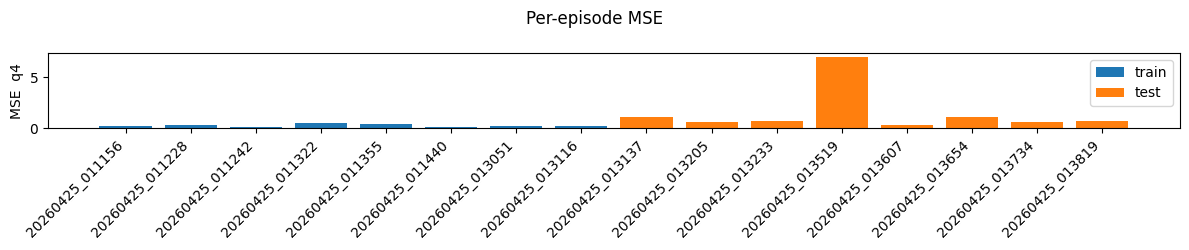

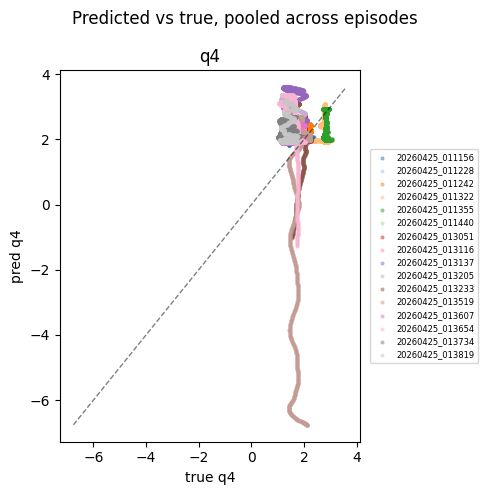

In [40]:
from scipy.stats import pearsonr

# Per-episode metrics.
rows = []
preds_per_ts = {}    # ts -> (Z, Z_hat) for the scatter below
for ts in timestamps:
    U_e, Z_e = UZ[ts]
    Z_hat_e  = model.predict(U_e)
    preds_per_ts[ts] = (Z_e, Z_hat_e)

    row = {'timestamp': ts, 'train': ts in train_ts}
    n_targets = Z_e.shape[1]
    for j in range(n_targets):
        target_name = JOINT_TARGETS[j] if (pca_joint is None and j < len(JOINT_TARGETS)) else f'Z{j+1}'
        err = Z_hat_e[:, j] - Z_e[:, j]
        mse = float(np.mean(err ** 2))
        ss_res = float(np.sum(err ** 2))
        ss_tot = float(np.sum((Z_e[:, j] - Z_e[:, j].mean()) ** 2))
        r2 = 1.0 - ss_res / ss_tot if ss_tot > 0 else float('nan')
        r  = float(pearsonr(Z_e[:, j], Z_hat_e[:, j])[0]) if Z_e.shape[0] > 1 else float('nan')
        row[f'mse_{target_name}']  = mse
        row[f'r2_{target_name}']   = r2
        row[f'pear_{target_name}'] = r
    rows.append(row)

metrics_df = pd.DataFrame(rows)
print(metrics_df.to_string(index=False))

# --- Bar chart: per-episode MSE per target, colored by train vs. test ---
target_names = [c[len('mse_'):] for c in metrics_df.columns if c.startswith('mse_')]
n_targets    = len(target_names)
plt.close('all')
fig, axes = plt.subplots(n_targets, 1, figsize=(12, 2.5 * n_targets), sharex=True)
if n_targets == 1:
    axes = [axes]
x = np.arange(len(metrics_df))
colors = ['tab:blue' if t else 'tab:orange' for t in metrics_df['train']]
for j, tname in enumerate(target_names):
    axes[j].bar(x, metrics_df[f'mse_{tname}'], color=colors)
    axes[j].set_ylabel(f'MSE  {tname}')
axes[-1].set_xticks(x)
axes[-1].set_xticklabels(metrics_df['timestamp'], rotation=45, ha='right')
# Manual legend.
from matplotlib.patches import Patch
axes[0].legend(handles=[Patch(facecolor='tab:blue',   label='train'),
                        Patch(facecolor='tab:orange', label='test')],
               loc='upper right')
plt.suptitle('Per-episode MSE')
plt.tight_layout()
plt.show()

# --- Pooled scatter: predicted vs. true, colored by episode, one subplot per target ---
fig, axes = plt.subplots(1, n_targets, figsize=(5 * n_targets, 5), squeeze=False)
axes = axes[0]
cmap = plt.get_cmap('tab20')
for j, tname in enumerate(target_names):
    ax = axes[j]
    all_z = []
    for k, ts in enumerate(timestamps):
        Z_e, Z_hat_e = preds_per_ts[ts]
        ax.scatter(Z_e[:, j], Z_hat_e[:, j], s=4, alpha=0.4,
                   color=cmap(k % 20), label=ts)
        all_z.append(Z_e[:, j]); all_z.append(Z_hat_e[:, j])
    lo, hi = float(np.min(np.concatenate(all_z))), float(np.max(np.concatenate(all_z)))
    ax.plot([lo, hi], [lo, hi], 'k--', alpha=0.5, linewidth=1)
    ax.set_xlabel(f'true {tname}')
    ax.set_ylabel(f'pred {tname}')
    ax.set_title(tname)
axes[-1].legend(fontsize=6, loc='center left', bbox_to_anchor=(1.02, 0.5))
plt.suptitle('Predicted vs true, pooled across episodes')
plt.tight_layout()
plt.show()


### 6c. Active episode selection

The visualizations below (prediction plots, cross-correlation, joint plot, 3D arm animation) all read from `ep`. Edit `ACTIVE_EPISODE` in this cell and rerun this cell + the cells below to switch episodes — no model refit needed.


In [43]:
from types import SimpleNamespace

ACTIVE_EPISODE = train_ts[0]   # <-- edit this one line to switch episodes


def get_episode(ts):
    """Bundle everything the §6d/6e/6f cells need for one episode."""
    if ts not in episodes:
        raise KeyError(f'{ts!r} not in loaded episodes: {list(episodes.keys())}')
    df = episodes[ts]
    U, Z = UZ[ts]
    Z_hat = model.predict(U)
    return SimpleNamespace(
        ts=ts,
        df=df,
        U=U,
        Z=Z,
        Z_hat=Z_hat,
        full_joint_data=df[joint_cols_all].values,
        is_train=(ts in train_ts),
    )


ep = get_episode(ACTIVE_EPISODE)
print(f'Active episode: {ep.ts}  (train={ep.is_train})  '
      f'U shape {ep.U.shape}  Z shape {ep.Z.shape}')


Active episode: 20260425_011156  (train=True)  U shape (1698, 2)  Z shape (1698, 1)


### 6d. Prediction plots — true vs predicted targets


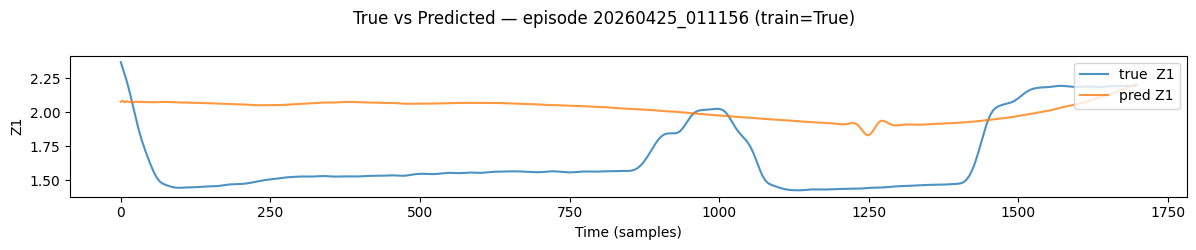

In [44]:
plt.close('all')
n_out = ep.Z.shape[1]
fig, ax = plt.subplots(n_out, 1, figsize=(12, 2.5*n_out), sharex=True)
if n_out == 1:
    ax = [ax]
for i in range(n_out):
    ax[i].plot(ep.Z[:, i],     label=f'true  Z{i+1}', alpha=0.8)
    ax[i].plot(ep.Z_hat[:, i], label=f'pred Z{i+1}', alpha=0.8)
    ax[i].set_ylabel(f'Z{i+1}')
    ax[i].legend(loc='upper right')
ax[-1].set_xlabel('Time (samples)')
plt.suptitle(f'True vs Predicted — episode {ep.ts} (train={ep.is_train})')
plt.tight_layout()
plt.show()


### 6e. Input/output cross-correlation (lag analysis)


In [152]:
from scipy.signal import correlate
from scipy.stats import pearsonr

U_a = ep.U
Z_a = ep.Z

print(f'Active episode: {ep.ts}')
print('Pearson correlations (per-channel):')
for i in range(min(U_a.shape[1], 4)):
    for j in range(Z_a.shape[1]):
        r, p = pearsonr(U_a[:, i], Z_a[:, j])
        print(f'  U{i+1} vs Z{j+1}: r={r:+.4f}  (p={p:.4f})')

print('\nCross-correlation peak lags:')
for i in range(min(U_a.shape[1], 4)):
    for j in range(Z_a.shape[1]):
        x = U_a[:, i] - U_a[:, i].mean()
        y = Z_a[:, j] - Z_a[:, j].mean()
        c = correlate(y, x, mode='full') / (np.std(x)*np.std(y)*len(x))
        lags = np.arange(-len(x)+1, len(x))
        peak_idx = np.argmax(np.abs(c))
        print(f'  U{i+1}->Z{j+1}: peak corr {c[peak_idx]:+.3f} at lag {lags[peak_idx]} samples')


Active episode: 20260425_011156
Pearson correlations (per-channel):
  U1 vs Z1: r=+0.0859  (p=0.0004)
  U2 vs Z1: r=+0.1940  (p=0.0000)

Cross-correlation peak lags:
  U1->Z1: peak corr -0.248 at lag -1239 samples
  U2->Z1: peak corr +0.318 at lag 300 samples


### 6f. Inverse PCA -> joint angles, then FK arm animation

If joint PCA was used, invert it back to (q1..q4). Otherwise we predicted joint columns directly; the remaining joints are filled in from ground truth so the FK animation has all four angles. Drives off the active episode.


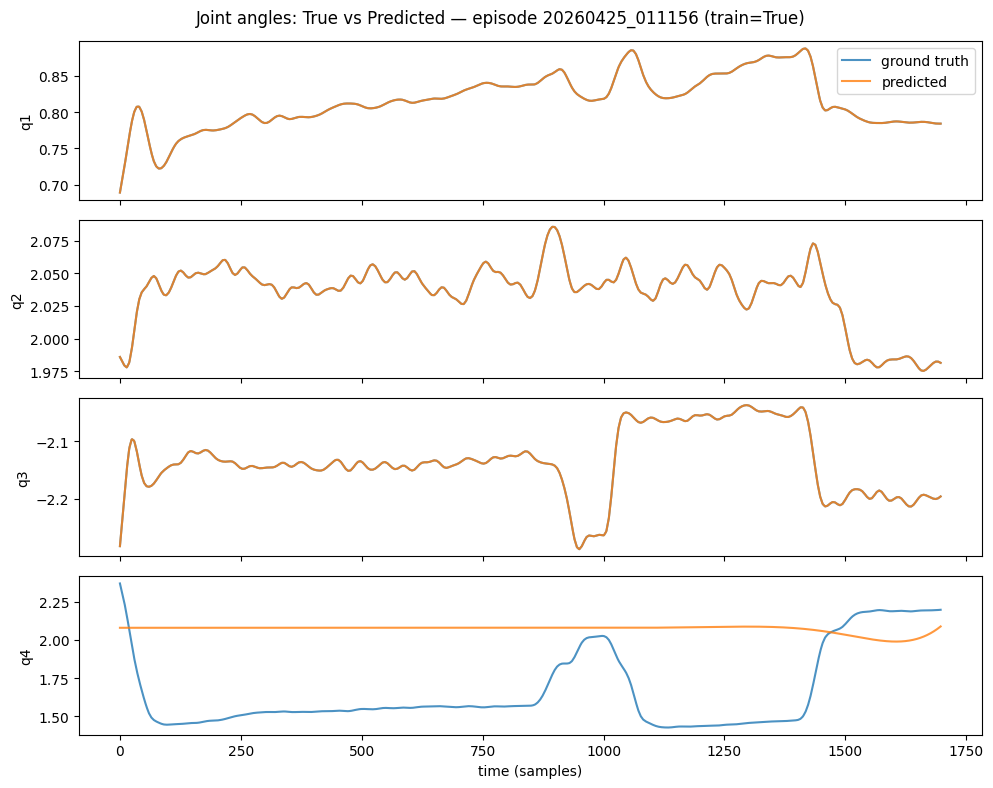

In [153]:
# Reconstruct full (q1..q4) from predictions for the active episode.
if pca_joint is not None:
    q_hat_full = pca_joint.inverse_transform(ep.Z_hat)
else:
    # Predictions only cover JOINT_TARGETS; copy ground truth for the rest.
    q_hat_full = ep.full_joint_data.copy()
    for k, col in enumerate(JOINT_TARGETS):
        col_idx = joint_cols_all.index(col)
        q_hat_full[:, col_idx] = ep.Z_hat[:, k]

q_gt_full = ep.full_joint_data

fig, ax = plt.subplots(4, 1, figsize=(10, 8), sharex=True)
for i, col in enumerate(joint_cols_all):
    ax[i].plot(q_gt_full[:, i],  label='ground truth', alpha=0.8)
    ax[i].plot(q_hat_full[:, i], label='predicted',    alpha=0.8)
    ax[i].set_ylabel(col)
ax[0].legend()
ax[-1].set_xlabel('time (samples)')
plt.suptitle(f'Joint angles: True vs Predicted — episode {ep.ts} (train={ep.is_train})')
plt.tight_layout()
plt.show()


In [12]:
# 3D arm animation: ground truth vs EMG-reconstructed (active episode).
T_full = q_hat_full.shape[0]
T_viz  = min(VIZ_DOWNSAMPLE_N, T_full)
step   = max(1, T_full // T_viz)
idx    = np.arange(0, T_full, step)[:T_viz]

q_gt_ds  = q_gt_full[idx]
q_hat_ds = q_hat_full[idx]
times    = ep.df['time'].values[idx]

viz = ArmVisualizer(fk_func=forward_kinematics_fixed, L1=L1_FIXED, L2=L2_FIXED)
viz.add_arm(name=f'Ground truth ({ep.ts})', color='green', dash='dash',
            q1=q_gt_ds[:, 0], q2=q_gt_ds[:, 1], q3=q_gt_ds[:, 2], q4=q_gt_ds[:, 3])
viz.add_arm(name=f'EMG-Reconstructed ({ep.ts})', color='yellow',
            q1=q_hat_ds[:, 0], q2=q_hat_ds[:, 1], q3=q_hat_ds[:, 2], q4=q_hat_ds[:, 3])
viz.show(times=times)


In [17]:
import numpy.linalg as la

In [20]:
la.eig(model.A)

EigResult(eigenvalues=array([1.00800366+0.0102846j, 1.00800366-0.0102846j]), eigenvectors=array([[0.28620962+0.16111769j, 0.28620962-0.16111769j],
       [0.94452377+0.j        , 0.94452377-0.j        ]]))

In [23]:
model.A

array([[ 1.02627323, -0.0072904 ],
       [ 0.06029165,  0.98973408]])

In [21]:
model.B

array([[-0.03226927, -0.02956076],
       [-0.09000467,  0.09989392]])

In [22]:
model.C

array([[ 3.02148698e-08, -6.52228659e-08]])

In [24]:
model.A, model.B, model.C

(array([[ 1.02627323, -0.0072904 ],
        [ 0.06029165,  0.98973408]]),
 array([[-0.03226927, -0.02956076],
        [-0.09000467,  0.09989392]]),
 array([[ 3.02148698e-08, -6.52228659e-08]]))